# Tapex our fine-tuning methods v.s. original fine-tuning methods (TabMWP)

Analyze Tapex predictions: accuracy buckets (free-text, multi-choice, integer, decimal) and error-type distribution with sample errors.


In [25]:
import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# Paths (adjust if needed)
DATA_ROOT = "./data/tabmwp"
TEST_SPLIT = "test"
OUR_RESULTS_FILE = "/Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp7_tapex-base.json"
ORIGINAL_RESULTS_FILE = "/Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp8-original_tapex-base.json"



The training configuration is train on 5 epochs and 1000 training dataset and 1000 validation dataset.

Train_best.py for our methods
```
!python train_best.py \
    --data_root ../data/tabmwp \
    --output ../saved_models/tapex_best \
    --result_root ../results/tapex_best \
    --model tapex-base \
    --label exp7 \
    --epochs 5 \
    --batch_size 16 \
    --eval_batch_size 16 \
    --gpu 0 \
    --augment_ratio 0.3 \
    --use_table_tuning \
    --use_chain_of_thought \
    --use_structured_input \
    --use_curriculum \
    --save_predictions \
    --eval_split test \
    --train_num 1000\
    --val_num 1000
```
train.py fr original methods
```
!python train.py \
    --model tapex-base \
    --label exp8-original \
    --epochs 5 \
    --batch_size 16 \
    --eval_batch_size 16 \
    --gpu 0 \
    --save_all\
    --train_num 1000\
    --val_num 1000
```

In [26]:
# Load data and results
problems = json.load(open(os.path.join(DATA_ROOT, f"problems_{TEST_SPLIT}.json")))
our_res = json.load(open(OUR_RESULTS_FILE))
original_res = json.load(open(ORIGINAL_RESULTS_FILE))
our_results = our_res["results"]
original_results = original_res["results"]

print(f"problems length : ",len(problems), "our_result length : ", len(our_results), "original_result length : ", len(original_results))



problems length :  7686 our_result length :  7686 original_result length :  7686


In [27]:
# Compute accuracy via evaluate_acc.py for both runs (ours vs original)
import subprocess, shlex, re

data_file = os.path.join(DATA_ROOT, f"problems_{TEST_SPLIT}.json")


def run_eval(result_path):
    cmd = [
        "python", "evaluate_acc.py",
        "--data_file", data_file,
        "--result_root", os.path.dirname(result_path),
        "--result_files", os.path.basename(result_path),
    ]
    print("\nRunning evaluate_acc for", result_path)
    print(" ".join(shlex.quote(p) for p in cmd))
    proc = subprocess.run(cmd, text=True, capture_output=True)
    print(proc.stdout)
    print("Return code:", proc.returncode)

    # parse acc_* lines into a dict
    metrics = {}
    for line in proc.stdout.splitlines():
        line = line.strip()
        if not line.startswith("acc_"):
            continue
        key = line.split(":", 1)[0].replace("acc_", "").upper()
        m = re.search(r"[-+]?[0-9]*\.?[0-9]+", line)
        if m:
            metrics[key] = float(m.group())
    return metrics


def normalize_metrics(raw):
    remap = {
        "INTEGER": "INT",
        "DECIMAL": "DEC",
        "EXTRACTIVE": "EXTR",
        "BOOLEAN": "BOOL",
        "OTHER": "OTH",
        "AVERAGE": "AVG",
        "FREE": "FREE",
        "MC": "MC",
        "GRADE_1_6": "GRADE_1_6",
        "GRADE_7_8": "GRADE_7_8",
    }
    out = {}
    for k, v in raw.items():
        out[remap.get(k, k)] = v
    return out


ours_metrics = normalize_metrics(run_eval(OUR_RESULTS_FILE))
original_metrics = normalize_metrics(run_eval(ORIGINAL_RESULTS_FILE))




Running evaluate_acc for /Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp7_tapex-base.json
python evaluate_acc.py --data_file ./data/tabmwp/problems_test.json --result_root /Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex --result_files exp7_tapex-base.json
Data file:  ./data/tabmwp/problems_test.json
Result file: 
/Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp7_tapex-base.json
number of questions: 7686

acc_free: 	8.76
acc_mc: 	39.81
acc_integer: 	10.60
acc_decimal: 	1.63
acc_extractive: 	32.83
acc_boolean: 	47.67
acc_other: 	38.10
acc_grade_1_6: 	19.62
acc_grade_7_8: 	13.06
acc_average: 	16.81

& 8.76 & 39.81 & 10.60 & 1.63 & 32.83 & 47.67 & 38.10 & 19.62 & 13.06 & 16.81 \\

Return code: 0

Running evaluate_acc for /Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp8-original_tapex-base.json
python evaluate_acc.py --data_file ./data/tabmwp/problems_test.json --result_root /Users/scarlett/Code/PromptPG-Bryanch

,Metric,Ours,Original,Diff (Ours-Original)
0,FREE,8.76,16.49,-7.73
1,MC,39.81,47.29,-7.48
2,INT,10.60,19.72,-9.12
3,DEC,1.63,3.95,-2.32
4,EXTR,32.83,43.26,-10.43
5,BOOL,47.67,51.44,-3.77
6,OTH,38.10,49.52,-11.42
7,GRADE_1_6,1.00,1.00,0.00
8,GRADE_7_8,7.00,7.00,0.00
9,AVG,16.81,24.47,-7.66


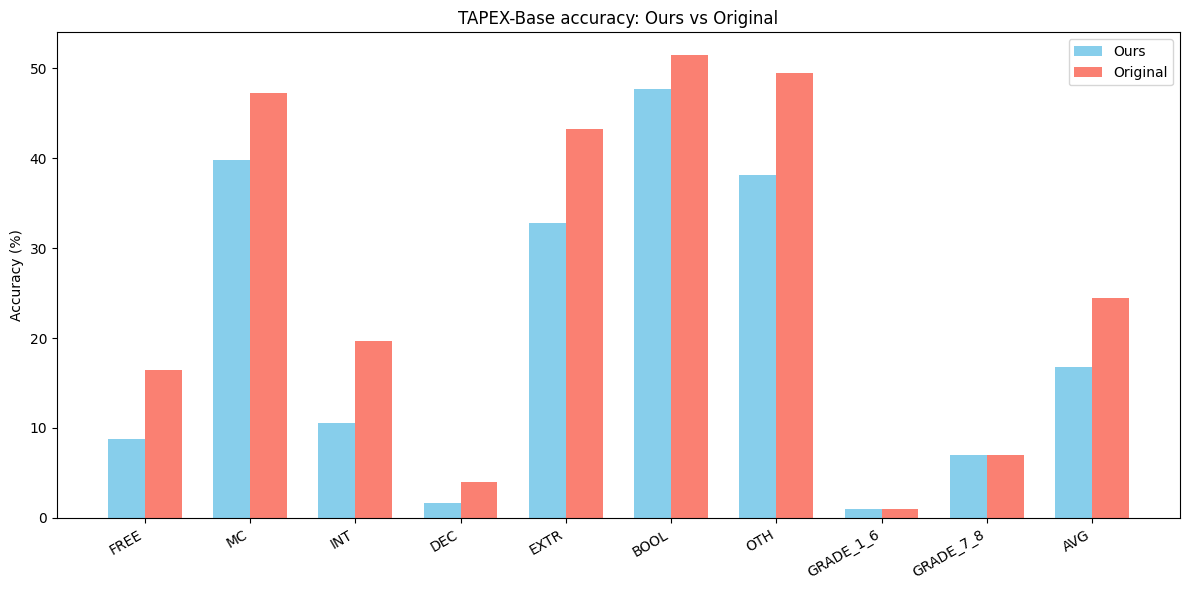

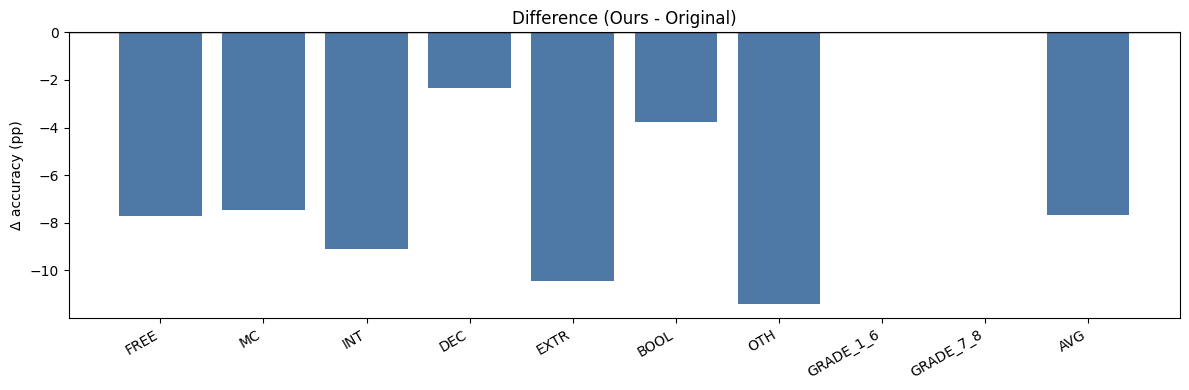

In [28]:
# Compare our TAPEX-base results (evaluate_acc outputs) vs original run
import pandas as pd
import matplotlib.pyplot as plt

metrics_order = [
    "FREE", "MC", "INT", "DEC", "EXTR", "BOOL", "OTH",
    "GRADE_1_6", "GRADE_7_8", "AVG",
]


def with_defaults(raw):
    filled = {k: float("nan") for k in metrics_order}
    filled.update(raw or {})
    return filled


ours = with_defaults(ours_metrics)
original = with_defaults(original_metrics)

metrics = metrics_order
df = pd.DataFrame({
    "Metric": metrics,
    "Ours": [ours[m] for m in metrics],
    "Original": [original[m] for m in metrics],
})
df["Diff (Ours-Original)"] = df["Ours"] - df["Original"]

# Tabular view
display(df)

# Bar plot: ours vs original
plt.figure(figsize=(12,6))
width = 0.35
x = range(len(metrics))
plt.bar([i - width/2 for i in x], df["Ours"], width=width, label="Ours", color="skyblue")
plt.bar([i + width/2 for i in x], df["Original"], width=width, label="Original", color="salmon")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("TAPEX-Base accuracy: Ours vs Original")
plt.legend()
plt.tight_layout()
plt.show()

# Difference plot
plt.figure(figsize=(12,4))
plt.bar(metrics, df["Diff (Ours-Original)"], color="#4e79a7")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ accuracy (pp)")
plt.title("Difference (Ours - Original)")
plt.tight_layout()
plt.show()


In [29]:
def try_float(x):
    try:
        return float(x)
    except Exception:
        return None

def categorize_error(ans, pred):
    num_a = try_float(ans)
    num_p = try_float(pred)

    if ans.lower() in {"yes","no","true","false"}:
        return "wrong_output_boolean" if ans.lower() != pred.lower() else None

    if num_a is None and num_p is None:
        if ans.lower() != pred.lower():
            return "text_mismatch"
        return None

    if num_a is not None and num_p is None:
        return "non_numeric"

    if num_a is None and num_p is not None:
        return "wrong_output_text"

    if math.isclose(num_a, num_p, rel_tol=0, abs_tol=1e-9):
        return None

    if round(num_a, 2) == round(num_p, 2):
        return "rounding_error"

    if math.isclose(abs(num_p), abs(num_a)*10, rel_tol=0.05) or math.isclose(abs(num_p)*10, abs(num_a), rel_tol=0.05):
        return "off_by_factor_10"

    diff = abs(num_p - num_a)
    if diff >= 10 and diff >= 0.2 * abs(num_a):
        return "large_calculation"
    else:
        return "small_calculation"


def get_error_distribution(results_dict):
    counter = Counter()
    for pid, prob in problems.items():
        r = results_dict.get(pid, {})
        if r.get("true_false", False):
            continue
        ans = str(r.get("answer_norm", r.get("answer", "")))
        pred = str(r.get("prediction_norm", r.get("prediction", "")))
        etype = categorize_error(ans, pred)
        counter[etype or "unknown"] += 1
    return counter



Error counts (ours):
  small_calculation: 3008
  large_calculation: 2044
  text_mismatch: 967
  wrong_output_boolean: 232
  off_by_factor_10: 117
  non_numeric: 24
  wrong_output_text: 2
  rounding_error: 0

Error counts (original):
  small_calculation: 3291
  large_calculation: 1432
  text_mismatch: 844
  wrong_output_boolean: 206
  off_by_factor_10: 20
  non_numeric: 9
  wrong_output_text: 2
  rounding_error: 1


,Error type,Ours,Original
0,small_calculation,3008,3291
1,large_calculation,2044,1432
2,text_mismatch,967,844
3,wrong_output_boolean,232,206
4,off_by_factor_10,117,20
5,non_numeric,24,9
6,wrong_output_text,2,2
7,rounding_error,0,1


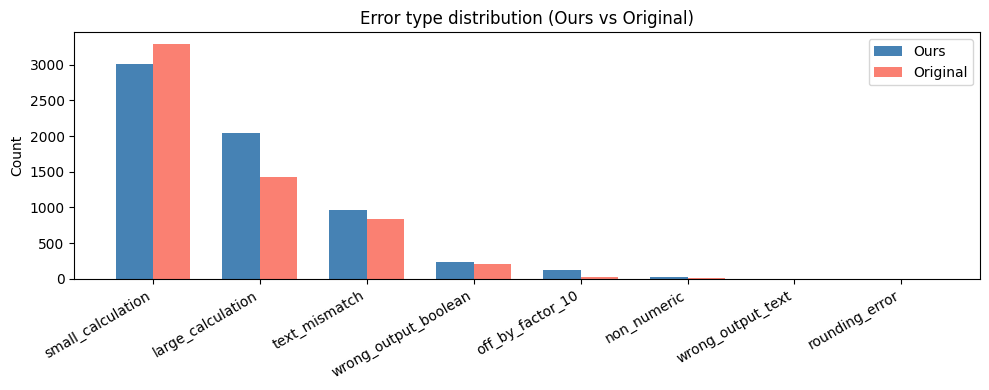

In [30]:
# Error distribution for both runs
err_ours = get_error_distribution(our_results)
err_orig = get_error_distribution(original_results)

all_err_types = [
    "small_calculation",
    "large_calculation",
    "text_mismatch",
    "wrong_output_boolean",
    "off_by_factor_10",
    "non_numeric",
    "wrong_output_text",
    "rounding_error"
]

print("Error counts (ours):")
for k in all_err_types:
    print(f"  {k}: {err_ours.get(k,0)}")
print("\nError counts (original):")
for k in all_err_types:
    print(f"  {k}: {err_orig.get(k,0)}")

# tabular view
err_df = pd.DataFrame({
    "Error type": all_err_types,
    "Ours": [err_ours.get(k, 0) for k in all_err_types],
    "Original": [err_orig.get(k, 0) for k in all_err_types],
})
display(err_df)

# grouped bar chart
plt.figure(figsize=(10,4))
x = range(len(all_err_types))
width = 0.35
plt.bar([i - width/2 for i in x], [err_ours.get(k,0) for k in all_err_types], width=width, label="Ours", color="steelblue")
plt.bar([i + width/2 for i in x], [err_orig.get(k,0) for k in all_err_types], width=width, label="Original", color="salmon")
plt.xticks(x, all_err_types, rotation=30, ha='right')
plt.ylabel("Count")
plt.title("Error type distribution (Ours vs Original)")
plt.legend()
plt.tight_layout()
plt.show()



In [31]:
# Show a few errors by type
sampled = defaultdict(list)
for pid, prob in problems.items():
    r = our_results[pid]
    if r.get("true_false", False):
        continue
    etype = categorize_error(str(r.get("answer_norm", r.get("answer", ""))), str(r.get("prediction_norm", r.get("prediction", ""))))
    if etype and len(sampled[etype]) < 3:
        sampled[etype].append((pid, prob.get("question", ""), r.get("answer"), r.get("output"), r.get("prediction")))

for etype, rows in sampled.items():
    print(f"\nError type: {etype}")
    for pid, q, ans, out, pred in rows:
        print(f"- pid {pid}\n  Q: {q}\n  answer: {ans}\n  output: {out}\n  prediction: {pred}\n")




Error type: large_calculation
- pid 8
  Q: Hannah baked cookies each day for a bake sale. How many more cookies did Hannah bake on Saturday than on Sunday?
  answer: 18
  output: Find the rows for 281 and 284. Add the numbers for these rows.

Add:

163 + 264 = 1320

1320

1320

Now subtract:

1320 − 1320 = 1320

Now divide the sum by the number of cookies:

1320 − 1320 = 1320

Now divide the sum by the number of cookies:

1320 − 1320 = 1320

Now
  prediction: 1320

- pid 30
  Q: Some friends played a trivia game and recorded their scores. How many more points did Hannah score than Dustin?
  answer: 650
  output: Find the numbers in the table.

770, 770, 886, 223

First, find the greatest number. The greatest number is 886.

Next, find the least number. The least number is 886.

Subtract the least number from the greatest number:

886 − 886 = 872

The least number is 872.
Answer: 872
  prediction: 872

- pid 53
  Q: Paula's family went on a road trip and counted the number of cars they

,epoch,train_loss,val_loss,method
0,1,3.7384,1.7790,ours
1,2,1.2226,0.7186,ours
2,3,0.6560,0.4872,ours
3,4,0.4479,0.3503,ours
4,5,0.3301,0.2251,ours
5,1,1.9490,0.8440,original
6,2,0.7220,0.7530,original
7,3,0.6410,0.7610,original
8,4,0.5210,0.7340,original
9,5,0.4320,0.7430,original


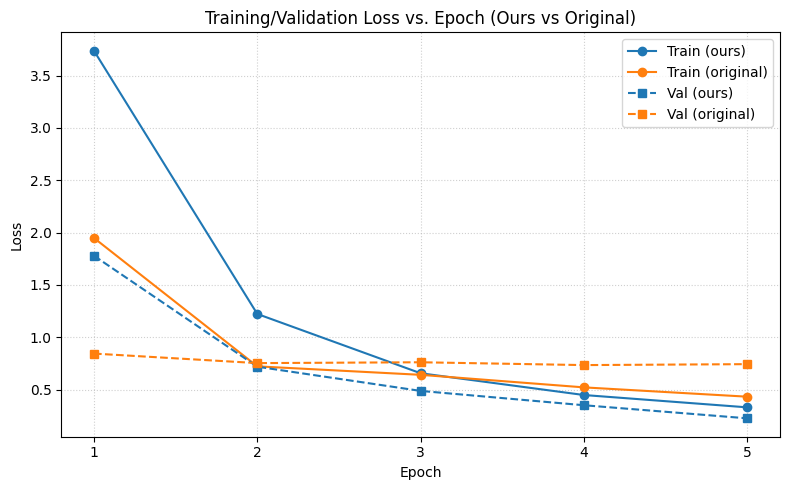

In [32]:
# Plot training loss and val loss in the training process
# Line chart comparison of training/validation loss (ours vs original)
import pandas as pd
import matplotlib.pyplot as plt

# Data from training logs
ours_epochs = [1, 2, 3, 4, 5]
ours_train = [3.7384, 1.2226, 0.6560, 0.4479, 0.3301]
ours_val = [1.7790, 0.7186, 0.4872, 0.3503, 0.2251]

orig_epochs = [1, 2, 3, 4, 5]
orig_train = [1.949, 0.722, 0.641, 0.521, 0.432]
orig_val = [0.844, 0.753, 0.761, 0.734, 0.743]

df = pd.DataFrame({
    "epoch": ours_epochs + orig_epochs,
    "train_loss": ours_train + orig_train,
    "val_loss": ours_val + orig_val,
    "method": ["ours"] * len(ours_epochs) + ["original"] * len(orig_epochs),
})

display(df)

plt.figure(figsize=(8,5))
# Train losses
plt.plot(df[df.method=="ours"]["epoch"], df[df.method=="ours"]["train_loss"], marker="o", label="Train (ours)", color="#1f77b4")
plt.plot(df[df.method=="original"]["epoch"], df[df.method=="original"]["train_loss"], marker="o", label="Train (original)", color="#ff7f0e")
# Val losses
plt.plot(df[df.method=="ours"]["epoch"], df[df.method=="ours"]["val_loss"], marker="s", linestyle="--", label="Val (ours)", color="#1f77b4")
plt.plot(df[df.method=="original"]["epoch"], df[df.method=="original"]["val_loss"], marker="s", linestyle="--", label="Val (original)", color="#ff7f0e")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, 6), [1, 2, 3, 4, 5])
plt.title("Training/Validation Loss vs. Epoch (Ours vs Original)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



# Our method shows :
* Training loss decreases, 
* Validation loss decreases,
* Validation loss < Training loss

# original Tapex baseline show :
* Training loss decreases
* Validation loss stays the same or increases

## Why 
Our method shows decreasing training and validation loss - and the validation loss is even lower - because : 
1. Chain-of-thought produces longer training targets, making traiing loss artificially higher while validation (with short answer) is lower.
2. Curriculum learning stabilizes training, making the model generalize earlier and better.
3. Structured table formatting reduces input complexity, improving validation loss significantly.
4. Synthenic QA tasks (table-tuning) act as regularization, preventing overfitting.

The original method lacks all these features, so 
* trainig loss drops,
* validation loss stays flat or rises because the model overfits or struggles with raw table parsing.

# Why our model has lower loss curves but worse final accuracy than the original paper

Some explaination fro ChatGPT

**Answer :  The model learned to generate "beautiful reasoing text", not correct numerical answers.**

This is the core problem.

Our modifications (CoT, augementation, structured input, curriculum) improved loss stability, but accidentally changed the training objective.

The model now optimizes for : 
* Fluency
* Step-by-step text strucutre
* Producing long explanations

but doesn't optimize :
* accurate quantitative reasoning
* precise table lookups
* consistent operations

This is why :  
- The training/val loss is low (because CoT text matches the expected pattern)
- But accuracy is much lower (because the final numerical answer are wrong)
Our CoT target is long and predictable 
```
Find the rows...
Add the numbers...
Now divide...
Answer: xxx
```
Even if the final number is wrong, the CoT text matches well, so the loss is low

But the answer is completely wrong and cause the accuracy drops.

----

So the main problem of that I introduce chain-of-Thought without controlling answer correctness.
The original Tapex paper finetunes on short answers only:

No CoT

No intermediate steps

Only the final number/word

This forces the model to optimize exactly the metric used at evaluation.

You changed the target format.
